In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve
)

import joblib

In [2]:
video = pd.read_csv(r"C:\Users\Rushikesh\Downloads\video_telemetry.csv")
events = pd.read_csv(r"C:\Users\Rushikesh\Downloads\system_events.csv")

print("Video Dataset")
print(video.head())

print("\nSystem Events Dataset")
print(events.head())

Video Dataset
             timestamp  eye_gaze_angle   audio_db
0  2023-12-01 08:00:00        2.560857  36.553781
1  2023-12-01 08:00:01       10.177137  39.102627
2  2023-12-01 08:00:02        5.761714  31.228565
3  2023-12-01 08:00:03        9.787105  34.051405
4  2023-12-01 08:00:04        4.572665  35.245018

System Events Dataset
                    timestamp  tab_switches  is_cheating
0  2023-12-01 08:00:32.181296             1            0
1  2023-12-01 08:01:01.923778             1            1
2  2023-12-01 08:01:24.462808             1            0
3  2023-12-01 08:04:10.610743             1            0
4  2023-12-01 08:04:23.902814             1            0


In [3]:
print(video.info())
print()

print(events.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   timestamp       10000 non-null  object 
 1   eye_gaze_angle  9268 non-null   float64
 2   audio_db        9268 non-null   float64
dtypes: float64(2), object(1)
memory usage: 234.5+ KB
None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   timestamp     167 non-null    object
 1   tab_switches  167 non-null    int64 
 2   is_cheating   167 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 4.0+ KB
None


In [4]:
print(video.isnull().sum())
print(events.isnull().sum())

timestamp           0
eye_gaze_angle    732
audio_db          732
dtype: int64
timestamp       0
tab_switches    0
is_cheating     0
dtype: int64


In [5]:
video["timestamp"] = pd.to_datetime(video["timestamp"])
events["timestamp"] = pd.to_datetime(events["timestamp"])

video = video.sort_values("timestamp")
events = events.sort_values("timestamp")

In [6]:
video = video.interpolate(numeric_only=True)
video = video.ffill()
video = video.bfill()

print(video.isnull().sum())

timestamp         0
eye_gaze_angle    0
audio_db          0
dtype: int64


In [7]:
data = pd.merge_asof(
    video,
    events,
    on="timestamp",
    direction="nearest"
)

print(data.head())
print(data.columns)

            timestamp  eye_gaze_angle   audio_db  tab_switches  is_cheating
0 2023-12-01 08:00:00        2.560857  36.553781             1            0
1 2023-12-01 08:00:01       10.177137  39.102627             1            0
2 2023-12-01 08:00:02        5.761714  31.228565             1            0
3 2023-12-01 08:00:03        9.787105  34.051405             1            0
4 2023-12-01 08:00:04        4.572665  35.245018             1            0
Index(['timestamp', 'eye_gaze_angle', 'audio_db', 'tab_switches',
       'is_cheating'],
      dtype='object')


In [8]:
print(data.columns)

Index(['timestamp', 'eye_gaze_angle', 'audio_db', 'tab_switches',
       'is_cheating'],
      dtype='object')


In [9]:
# Rolling Window Features (10 observations)

data["eye_gaze_roll10"] = data["eye_gaze_angle"].rolling(
    window=10,
    min_periods=1
).mean()

data["audio_roll10"] = data["audio_db"].rolling(
    window=10,
    min_periods=1
).mean()

data["tab_roll10"] = data["tab_switches"].rolling(
    window=10,
    min_periods=1
).mean()

print(data.head())

            timestamp  eye_gaze_angle   audio_db  tab_switches  is_cheating  \
0 2023-12-01 08:00:00        2.560857  36.553781             1            0   
1 2023-12-01 08:00:01       10.177137  39.102627             1            0   
2 2023-12-01 08:00:02        5.761714  31.228565             1            0   
3 2023-12-01 08:00:03        9.787105  34.051405             1            0   
4 2023-12-01 08:00:04        4.572665  35.245018             1            0   

   eye_gaze_roll10  audio_roll10  tab_roll10  
0         2.560857     36.553781         1.0  
1         6.368997     37.828204         1.0  
2         6.166569     35.628325         1.0  
3         7.071703     35.234095         1.0  
4         6.571896     35.236279         1.0  


In [10]:
X = data[[
    "eye_gaze_angle",
    "audio_db",
    "tab_switches",
    "eye_gaze_roll10",
    "audio_roll10",
    "tab_roll10"
]]

y = data["is_cheating"]

print(X.head())
print(y.head())

   eye_gaze_angle   audio_db  tab_switches  eye_gaze_roll10  audio_roll10  \
0        2.560857  36.553781             1         2.560857     36.553781   
1       10.177137  39.102627             1         6.368997     37.828204   
2        5.761714  31.228565             1         6.166569     35.628325   
3        9.787105  34.051405             1         7.071703     35.234095   
4        4.572665  35.245018             1         6.571896     35.236279   

   tab_roll10  
0         1.0  
1         1.0  
2         1.0  
3         1.0  
4         1.0  
0    0
1    0
2    0
3    0
4    0
Name: is_cheating, dtype: int64


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (8000, 6)
Testing Shape  : (2000, 6)


In [12]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

print("✅ Model Training Complete")

✅ Model Training Complete


In [13]:
prob = model.predict_proba(X_test)[:, 1]

prediction = (prob >= 0.90).astype(int)

print(prediction[:10])

[0 0 0 0 0 0 0 1 0 0]


In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, prediction))
print("Precision:", precision_score(y_test, prediction))
print("Recall   :", recall_score(y_test, prediction))
print("F1 Score :", f1_score(y_test, prediction))

print("\nClassification Report")
print(classification_report(y_test, prediction))

Accuracy : 0.8725
Precision: 1.0
Recall   : 0.6148036253776435
F1 Score : 0.7614593077642656

Classification Report
              precision    recall  f1-score   support

           0       0.84      1.00      0.91      1338
           1       1.00      0.61      0.76       662

    accuracy                           0.87      2000
   macro avg       0.92      0.81      0.84      2000
weighted avg       0.89      0.87      0.86      2000



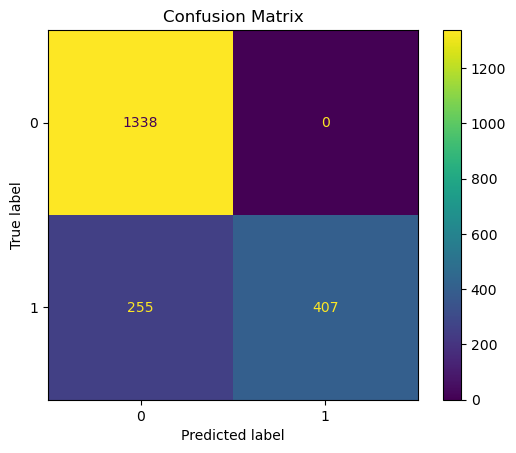

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, prediction)

plt.title("Confusion Matrix")
plt.show()

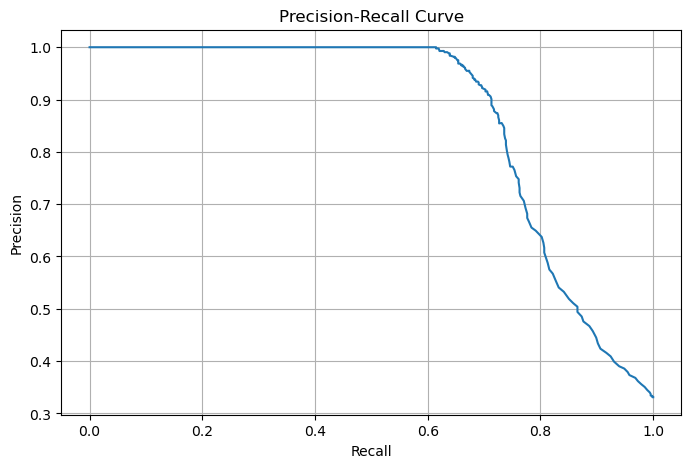

In [16]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, prob)

plt.figure(figsize=(8,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.show()

In [17]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

print(importance)

           Feature  Importance
2     tab_switches    0.222670
5       tab_roll10    0.189386
3  eye_gaze_roll10    0.166188
4     audio_roll10    0.156802
0   eye_gaze_angle    0.137185
1         audio_db    0.127769


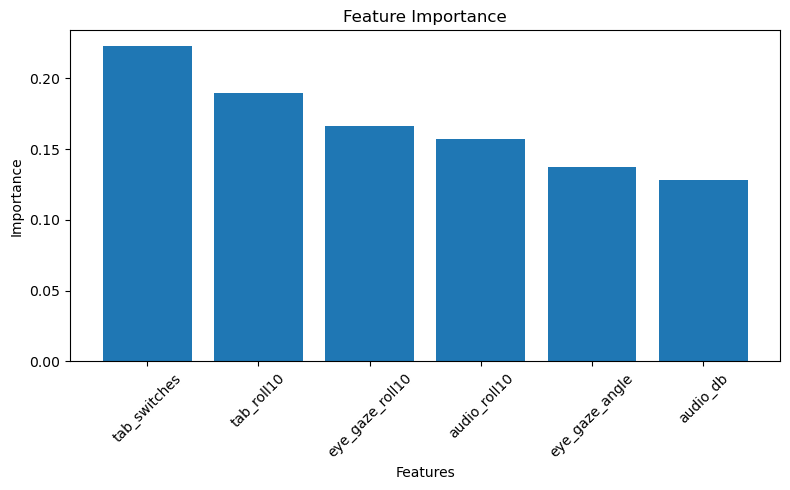

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(importance["Feature"], importance["Importance"])
plt.xticks(rotation=45)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

In [19]:
data.to_csv("final_exam_dataset.csv", index=False)

print("✅ Dataset Saved Successfully")

✅ Dataset Saved Successfully


In [20]:
import joblib

joblib.dump(model, "panopticon_model.pkl")

print("✅ Model Saved Successfully")

✅ Model Saved Successfully


In [21]:
sample = pd.DataFrame({
    "eye_gaze_angle": [40],
    "audio_db": [70],
    "tab_switches": [2],
    "eye_gaze_roll10": [35],
    "audio_roll10": [65],
    "tab_roll10": [1]
})

probability = model.predict_proba(sample)[0][1]

print("Cheating Probability:", round(probability, 3))

if probability >= 0.90:
    print("⚠ Suspicious Student")
else:
    print("✅ Normal Student")

Cheating Probability: 0.845
✅ Normal Student


In [22]:
import os

print(os.getcwd())

print("\nFiles in current folder:")
for file in os.listdir():
    print(file)

C:\Users\RUSHIKESH\eclipse-workspace

Files in current folder:
.ipynb_checkpoints
.metadata
Advance_Java_JDBC
final_exam_dataset.csv
Hibernate-Workspace
Java_Course
panopticon_model.pkl
Untitled.ipynb
